# Limpieza de bienes raíces

Este es un conjunto de datos (dataset) reales que fue descargado usando técnicas de web scraping. La data contiene registros de **Fotocasa**, el cual es uno de los sitios más populares de bienes raíces en España. Por favor no hagas esto (web scraping) a no ser que sea para propósitos académicos.

El dataset fue descargado hace algunos años por Henry Navarro y en ningún caso se obtuvo beneficio económico de ello.

Contiene miles de datos de casas reales publicadas en la web www.fotocasa.com. Tu objetivo es extraer tanta información como sea posible con el conocimiento que tienes hasta ahora de ciencia de datos, por ejemplo ¿cuál es la casa más cara en todo el dataset?

Empecemos precisamente con esa pregunta... ¡Buena suerte!

#### Ejercicio 00. Lee el dataset assets/real_estate.csv e intenta visualizar la tabla (★☆☆)

In [320]:
import pandas as pd

# Este archivo CSV contiene puntos y comas en lugar de comas como separadores; assets/real_estate.csv
ds = pd.read_csv('assets/real_estate.csv', sep=';')
ds

,Unnamed: 0,id_realEstates,isNew,realEstate_name,phone_realEstate,url_inmueble,rooms,bathrooms,surface,price,...,level4Id,level5Id,level6Id,level7Id,level8Id,accuracy,latitude,longitude,zipCode,customZone
0,1,153771986,False,ferrari 57 inmobiliaria,912177526.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,103.0,195000,...,0,0,0,0,0,0,"40,2948276786438","-3,44402412135624",NaN,NaN
1,2,153867863,False,tecnocasa fuenlabrada ferrocarril,916358736.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,NaN,89000,...,0,0,0,0,0,1,"40,28674","-3,79351",NaN,NaN
2,3,153430440,False,look find boadilla,916350408.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,2.0,2.0,99.0,390000,...,0,0,0,0,0,0,"40,4115646786438","-3,90662252135624",NaN,NaN
3,4,152776331,False,tecnocasa fuenlabrada ferrocarril,916358736.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,86.0,89000,...,0,0,0,0,0,0,"40,2853785786438","-3,79508142135624",NaN,NaN
4,5,153180188,False,ferrari 57 inmobiliaria,912177526.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,2.0,2.0,106.0,172000,...,0,0,0,0,0,0,"40,2998774864376","-3,45226301356237",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15330,15331,153901377,False,infocasa consulting,911360461.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,2.0,1.0,96.0,259470,...,0,0,0,0,0,0,"40,45416","-3,70286",NaN,NaN
15331,15332,150394373,False,inmobiliaria pulpon,912788039.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,1.0,150.0,165000,...,0,0,0,0,0,0,"40,36652","-3,48951",NaN,NaN
15332,15333,153901397,False,tecnocasa torrelodones,912780348.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,4.0,2.0,175.0,495000,...,0,0,0,0,0,0,"40,57444","-3,92124",NaN,NaN
15333,15334,152607440,False,inmobiliaria pulpon,912788039.0,https://www.fotocasa.es/es/comprar/vivienda/ma...,3.0,2.0,101.0,195000,...,0,0,0,0,0,0,"40,36967","-3,48105",NaN,NaN


#### Ejercicio 01. ¿Cuál es la casa más cara en todo el dataset? (★☆☆)

Imprime la dirección y el precio de la casa seleccionada. Por ejemplo:

`La casa con dirección en Calle del Prado, Nº20 es la más cara y su precio es de 5000000 USD`

In [321]:
casa_cara = ds["price"].max()
direccion_casa_cara=ds[ds['price']==casa_cara]['address'].iloc[0]

print(f"La casa con direccion en {direccion_casa_cara}, es la más cara y su precio es de {casa_cara} USD")

La casa con direccion en El Escorial, es la más cara y su precio es de 8500000 USD


#### Ejercicio 02. ¿Cuál es la casa más barata del dataset? (★☆☆)

Imprime la dirección y el precio de la casa seleccionada. Por ejemplo:

`La casa con dirección en Calle Alcalá, Nº58 es la más barata y su precio es de 12000 USD`

In [322]:
ds_non_cero_price = ds[ds['price'] >= 2] #para no incluir las casas sin precio que suelen salir con 0 o 1 en idealista. 
precio_casa_barata=ds_non_cero_price['price'].min()
direccion_casa_barata=ds_non_cero_price[ds_non_cero_price['price']==precio_casa_barata]['address'].iloc[0]
print(f"La casa con direccion en {direccion_casa_barata}, es la más barata y su precio es de {precio_casa_barata} USD")

La casa con direccion en Berlin, Coslada, es la más barata y su precio es de 600 USD


#### Ejercicio 03. ¿Cuál es la casa más grande y la más pequeña del dataset? (★☆☆)

Imprime la dirección y el área de las casas seleccionadas. Por ejemplo:

`La casa más grande está ubicada en Calle Gran Vía, Nº38 y su superficie es de 5000 metros`

`La casa más pequeña está ubicada en Calle Mayor, Nº12 y su superficie es de 200 metros`

In [323]:
casa_grande=ds['surface'].max()
id_casa_grande=ds['surface'].idxmax()
direccion_casa_grande= ds.loc[id_casa_grande, "address"]
superfice_max= ds.loc[id_casa_grande, "surface"]

casa_pequeña=ds['surface'].min()
id_casa_pequeña=ds['surface'].idxmin()
direccion_casa_pequeña= ds.loc[id_casa_pequeña, "address"]
superfice_min= ds.loc[id_casa_pequeña, "surface"]

print(f"La casa más grande está ubicada en {direccion_casa_grande}, y su superficie es de {superfice_max} metros")
print(f"La casa más grande pequeña ubicada en {direccion_casa_pequeña}, y su superficie es de {superfice_min} metros")

La casa más grande está ubicada en Sevilla la Nueva, y su superficie es de 249000.0 metros
La casa más grande pequeña ubicada en Calle Amparo,  Madrid Capital, y su superficie es de 15.0 metros


#### Ejercicio 04. ¿Cuantas poblaciones (columna level5) contiene el dataset? (★☆☆)

Imprime el nombre de las poblaciones separadas por coma. Por ejemplo:

`> print(populations)`

`population1, population2, population3, ...`

In [324]:
#entiendo que lo que pide son las poblaciones únicas,es decir contar sólo la primera vez que ocurren
populations=ds['level5'].unique()
print(f"El número de poblaciones únicas es {populations.shape[0]}")
#imprimir las populations separadas por comas y convertir en linea string para poder visualizar mejor
populations_str=','.join(map(str, populations))
print(populations_str)

El número de poblaciones únicas es 168
Arganda del Rey,Fuenlabrada,Boadilla del Monte,Las Rozas de Madrid, Madrid Capital,Villaviciosa de Odón,Pinto,Valdemoro,Navalcarnero,Pozuelo de Alarcón,Torrejón de Ardoz,Navalagamella,San Sebastián de los Reyes,Rivas-vaciamadrid,Alpedrete,Móstoles,San Fernando de Henares,Coslada,Becerril de la Sierra,Alcalá de Henares,Chinchón,Parla,Alcorcón,El Escorial,Leganés,Pedrezuela,Majadahonda,Villanueva de la Cañada,Villanueva del Pardillo,Torrelodones,Moralzarzal,Mejorada del Campo,Aranjuez,Corpa,Getafe,Velilla de San Antonio,Sevilla la Nueva,San Martín de la Vega,Villalbilla,Collado Villalba,Alcobendas,El Molar (Madrid),Moraleja de Enmedio,Algete,Campo Real,Torrejón de la Calzada,Colmenar Viejo,Valdemorillo,Fuente El Saz de Jarama,Tres Cantos,Arroyomolinos (Madrid),Griñón,Paracuellos de Jarama,Guadarrama,Titulcia,Galapagar,Collado Mediano,Los Molinos,San Lorenzo de El Escorial,Loeches,San Martín de Valdeiglesias,Navas del Rey,Bustarviejo,Manzanares El Re

#### Ejercicio 05. ¿El dataset contiene valores no admitidos (NAs)? (★☆☆)

Imprima un booleano (`True` o `False`) seguido de la fila/columna que contiene el NAs.

In [325]:
print(ds.isnull().values.any())
nan_ds=ds.isnull()
for col in nan_ds:
    if nan_ds[col].any(): 
        print(f"{col}:  {nan_ds[col].to_list()}")

True
realEstate_name:  [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fal

#### Exercise 06. Delete the NAs of the dataset, if applicable (★★☆)

Print a comparison between the dimensions of the original DataFrame versus the DataFrame after the deletions.

In [326]:
newdf = ds.dropna()
print(ds.shape)
print(newdf.shape)
#todas las filas poseen al menos 1 valor nulo por eso ha eliminado todo el data set.
#eliminos las que tienen todos los valores nulos, pero sigue quedando el set vacio. Creo que lo mejor sería sustituir los valores nulos por 0 y ver como queda
ds_1=ds.drop("customZone",axis=1)
ds_1=ds_1.drop("zipCode",axis=1)
#print(ds_1.isnull().sum().sort_values().index[-1])
#print(ds_1["zipCode"].sum())

new_ds = ds_1.dropna()
print(new_ds.shape)





(15335, 37)
(0, 37)
(0, 35)


#### Ejercicio 07. ¿Cuál la media de precios en la población (columna level5) de "Arroyomolinos (Madrid)"? (★★☆)

Imprima el valor obtenido.

In [327]:

precios_Arr=ds[ds["level5"]=="Arroyomolinos (Madrid)"]["price"]
media_precios_Arr=precios_Arr.mean()
media_precios_Arr=round(media_precios_Arr,2)
print(f"La media de precios de Arroyomolinos es de : {media_precios_Arr} euros")


La media de precios de Arroyomolinos es de : 294541.6 euros


#### Ejercicio 08. Trazar el histograma de los precios para la población (level5 column) de "Arroyomolinos (Madrid)" y explica qué observas (★★☆)

Imprime el histograma de los precios y escribe en la celda del Markdown un breve análisis del trazado.


Text(0.5, 1.0, 'HISTOGRAMA PRECIOS ARROYOMOLINOS')

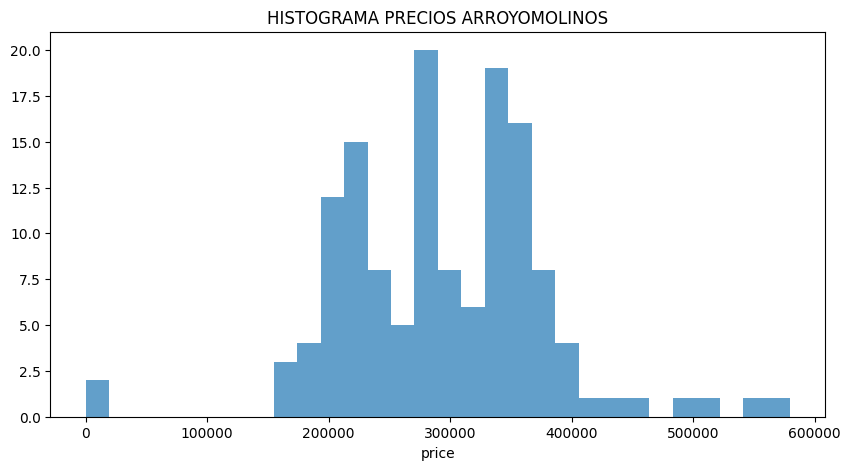

In [328]:
import numpy as np
import matplotlib.pyplot as plt

ds = pd.read_csv('assets/real_estate.csv', sep=';')
precios_arroyomolimos= ds.loc[ds['level5']=='Arroyomolinos (Madrid)', ['price']]

plt.figure(figsize = (10, 5))
plt.hist(precios_arroyomolimos, bins = 30, alpha = 0.7)
plt.xlabel('price')
plt.title('HISTOGRAMA PRECIOS ARROYOMOLINOS')

La gran mayoría de precios se situan entre los 170.000€ y los 400.000€, siendo especialmente notable la franja de entre 250.000 y 350.000€, con más de un 30% de los valores concentrados en este tramo, con el punto medio coinciente con el valor promedio.

#### Ejercicio 09. ¿Son los precios promedios de "Valdemorillo" y "Galapagar" los mismos? (★★☆)

Imprime ambos promedios y escribe una conclusión sobre ellos.

In [329]:
precios_valdemorillo=ds.loc[ds["level5"]=="Valdemorillo",["price"]]

precios_promedio_valdemorillo=precios_valdemorillo.mean().iloc[0]
print(f"Promedio precios Valdemorillo: {round(precios_promedio_valdemorillo,2)}")

precios_galapagar = ds.loc[ds["level5"] == "Galapagar", ["price"]]
precios_promedio_galapagar = precios_galapagar.mean().iloc[0]
print(f"Promedio precios Galapagar: {round(precios_promedio_galapagar, 2)}")


Promedio precios Valdemorillo: 363860.29
Promedio precios Galapagar: 360063.2


El precio promedio de Galapagar es de 360.063€ frente al de Valdemorillo de 363.860€, lo que implica que los precios medios son similares. PAra asegurarnos deberíamos haber comprobado antes que no existen valores nulos de precio, en los set y quizás despreciar los valores menores de 10.000€ que tambien pueden estar distorsionando, si en uno de los sets hay mayor oferta de alquileres o bien el precio es mayor.

#### Ejercicio 10. ¿Son los promedios de precio por metro cuadrado (precio/m2) de "Valdemorillo" y "Galapagar" los mismos? (★★☆)

Imprime ambos promedios de precio por metro cuadrado y escribe una conclusión sobre ellos.

Pista: Crea una nueva columna llamada `pps` (*price per square* o precio por metro cuadrado) y luego analiza los valores.

In [330]:

ds['pps'] = ds['price'] / ds['surface']
precios_pps_Valdemorillo=ds.loc[ds["level5"]=="Valdemorillo",["pps"]]
promedio_pps_Valdemorillo=precios_pps_Valdemorillo.mean().iloc[0]
print(f"El precio promedio (€/m2) de Valdemorillo es de: {round(promedio_pps_Valdemorillo,2)} €")

precios_pps_Galapagar = ds.loc[ds["level5"]=="Galapagar", ["pps"]]
promedio_pps_Galapagar = precios_pps_Galapagar.mean().iloc[0]
print(f"El precio promedio (€/m2) de Galapagar es de: {round(promedio_pps_Galapagar,2)}€")


El precio promedio (€/m2) de Valdemorillo es de: 1317.95 €
El precio promedio (€/m2) de Galapagar es de: 1606.32€


Temiendo en cuenta que los precios promedio de ambas localidaes son similares, como vimos antes, el hecho de que el pps de Galapagar sea de 1606€/m2 frente a los 1318 €/m2 de Valdemorillo, indica que los metros promedio de las viviendas en Galapagar son menores que el Valdemorillo. Habria que cotejar haciendo una práctica similar a esta pero con surface.

#### Ejercicio 11. Analiza la relación entre la superficie y el precio de las casas. (★★☆)

Pista: Puedes hacer un `scatter plot` y luego escribir una conclusión al respecto.

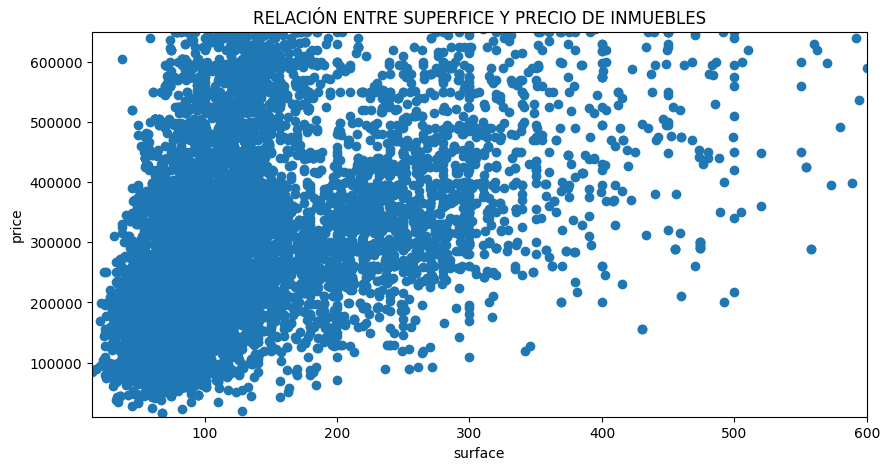

In [331]:

ds_filtered = ds[(ds['pps'].notna()) & (ds['pps'] != 0)]
plt.figure(figsize = (10, 5))
plt.xlim(15, 600)
plt.ylim(10000,650000) 
plt.scatter(ds_filtered['surface'], ds_filtered['price'])

plt.xlabel('surface')
plt.ylabel('price')
plt.title('RELACIÓN ENTRE SUPERFICE Y PRECIO DE INMUEBLES')

plt.show()

Hay valores sueltos no permiten ver correctamente la gráfca, por eso he modificado la escala (para hacerlo de forma correcta habría que intrudicr un test de student o tener en cuenta la varianza), pero dejando fuera los 5 valores que puedan distoriornar nás visualmetne, se aprecia que la mayor parte de los pisos tienen entre 50 y 150 metros, que la relación pps hace que los pisos con menos metros sean los más caros por metro cuadrado, es decir a la hora de valorar el precio, a partir de unos metros, la relación pps es menor. En relación al precio se observan 2 mercados, el mayoritario, donde los precios están por debajo de los 400.000€ y luego un conjunto menor, donde los precios entán entre los 450.000 y los 700.000€, probablemente debido a zonas donde el pps sea mucho mayor y tambien al mercado de casas en barrios de clase alta que sube mucho los precios. A partr de los 200m2 el mercado es minoritario y está más atomizado.

**TODO: Markdown**. Para escribir aquí, haz doble clic en esta celda, elimina este contenido y coloca lo que quieras escribir. Luego ejecuta la celda.

#### Ejercicio 12. ¿Cuántas agencia de bienes raíces contiene el dataset? (★★☆)

Imprime el valor obtenido.

In [332]:
# ds.columns >>  realEstate_name
listado_agencias= ds['realEstate_name'].nunique
print(listado_agencias)
total_agencias=ds['realEstate_name'].size
print("\n")
print(f'el número total de agencias es: {total_agencias}')

<bound method IndexOpsMixin.nunique of 0                  ferrari 57 inmobiliaria
1        tecnocasa fuenlabrada ferrocarril
2                       look find boadilla
3        tecnocasa fuenlabrada ferrocarril
4                  ferrari 57 inmobiliaria
                       ...                
15330                  infocasa consulting
15331                  inmobiliaria pulpon
15332               tecnocasa torrelodones
15333                  inmobiliaria pulpon
15334                  infocasa consulting
Name: realEstate_name, Length: 15335, dtype: object>


el número total de agencias es: 15335


#### Ejercicio 13. ¿Cuál es la población (columna level5) que contiene la mayor cantidad de casas?(★★☆)

Imprima la población y el número de casas.

In [333]:
conteo_casas = ds.groupby('level5').size()
print(conteo_casas)
print('\n')

poblacion_mayor_numero_casas = conteo_casas.idxmax()
max_numero_casas = conteo_casas.max()

print(f"La población con el mayor número de casas es {poblacion_mayor_numero_casas} con {max_numero_casas} casas.")

level5
 Madrid Capital          6643
Ajalvir                    17
Alcalá de Henares         525
Alcobendas                259
Alcorcón                  190
                         ... 
Villar del Olmo             7
Villarejo de Salvanés      19
Villaviciosa de Odón      166
Villavieja del Lozoya       6
Zarzalejo                   2
Length: 168, dtype: int64


La población con el mayor número de casas es  Madrid Capital con 6643 casas.


#### Ejercicio 14. Ahora vamos a trabajar con el "cinturón sur" de Madrid. Haz un subconjunto del DataFrame original que contenga las siguientes poblaciones (columna level5): "Fuenlabrada", "Leganés", "Getafe", "Alcorcón" (★★☆)

Pista: Filtra el DataFrame original usando la columna `level5` y la función `isin`.

In [334]:
filtro_poblaciones_cs= ["Fuenlabrada", "Leganés", "Getafe", "Alcorcón"]

subconjunto_cs = ds[ds['level5'].isin(filtro_poblaciones_cs)]

print(subconjunto_cs)



       Unnamed: 0  id_realEstates  isNew  \
1               2       153867863  False   
3               4       152776331  False   
85             86       153152077  False   
94             95       153995577  False   
109           110       153586414  False   
...           ...             ...    ...   
15275       15276       153903887  False   
15291       15292       151697757  False   
15305       15306       153902389  False   
15322       15323       153871864  False   
15325       15326       153901467  False   

                                 realEstate_name  phone_realEstate  \
1              tecnocasa fuenlabrada ferrocarril       916358736.0   
3              tecnocasa fuenlabrada ferrocarril       916358736.0   
85                       sinergical inmobiliaria               NaN   
94                               viviendas365com       911226014.0   
109              area uno asesores inmobiliarios       912664081.0   
...                                          ...   

#### Exercise 15. Make a bar plot of the median of the prices and explain what you observe (you must use the subset obtained in Exercise 14) (★★★)

Print the bar of the median of the prices and write in the Markdown cell a brief analysis about the plot.

level5
Alcorcón       179500.0
Fuenlabrada    155000.0
Getafe         285305.0
Leganés        169950.0
Name: price, dtype: float64


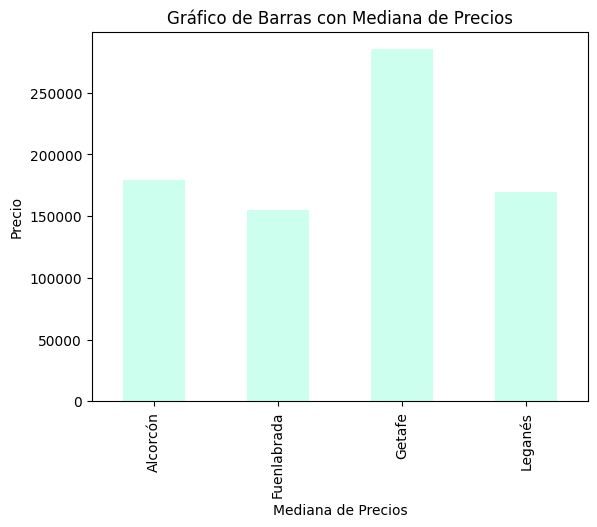

In [335]:
mediana_precios_ciudad = subconjunto_cs.groupby('level5')['price'].median()
# Mostrar el resultado
print(mediana_precios_ciudad)

mediana_precios_ciudad.plot(kind='bar', color='#ccffee')
# Añadir etiquetas y título
plt.xlabel('Mediana de Precios')
plt.ylabel('Precio')
plt.title('Gráfico de Barras con Mediana de Precios')

plt.show()




Getafe alcanza el valor más alto en relación a la mediana, es decir el valor que representa el punto medio de la distribución de precios.El valor más bajo en relación a la mediana lo obtienen Fuenlabrada, en torno a 150.000€

#### Ejercicio 16. Calcula la media y la varianza de muestra para las siguientes variables: precio, habitaciones, superficie y baños (debes usar el subconjunto obtenido del Ejercicio 14) (★★★)

Imprime ambos valores por cada variable.

In [336]:

#trabajar con vista
subconjunto_cs.loc[:, ['price', 'rooms', 'surface', 'bathrooms']] = subconjunto_cs[['price', 'rooms', 'surface', 'bathrooms']].astype(float)


# Calcular la media y la varianza de muestra
medias = subconjunto_cs[['price', 'rooms', 'surface', 'bathrooms']].mean()
varianzas = subconjunto_cs[['price', 'rooms', 'surface', 'bathrooms']].var()

# Crear DataFrame con los resultados
resultados = pd.DataFrame({'Media': medias, 'Varianza': varianzas})

print("Media y Varianza de Muestra para las Variables:")
print(resultados)

Media y Varianza de Muestra para las Variables:
                   Media      Varianza
price      223094.480706  1.492137e+10
rooms           3.017738  7.188859e-01
surface       111.752224  4.263052e+03
bathrooms       1.633222  5.717969e-01


#### Ejercicio 17. ¿Cuál es la casa más cara de cada población? Debes usar el subset obtenido en la pregunta 14 (★★☆)

Imprime tanto la dirección como el precio de la casa seleccionada de cada población. Puedes imprimir un DataFrame o una sola línea para cada población.

In [337]:
cinturon_sur_sorted = subconjunto_cs.sort_values(by=['level5', 'price'], ascending=[True, False])
casas_mas_caras = cinturon_sur_sorted.groupby('level5').first().reset_index()

for index, row in casas_mas_caras.iterrows():
    print(f"Población: {row['level5']}, Dirección: {row['address']}, Precio: {row['price']}")


Población: Alcorcón, Dirección: Alcorcón, Precio: 950000
Población: Fuenlabrada, Dirección: Calle de Paulo Freire, 5, Fuenlabrada, Precio: 490000
Población: Getafe, Dirección: Getafe, Precio: 1050000
Población: Leganés, Dirección: Avenida Reina Sofía, Leganés, Precio: 650000


#### Exercise 18. Normalize the variable of prices for each population and plot the 4 histograms in the same plot (you must use the subset obtained in Exercise 14) (★★★)

For the normalization method, you can use the one you consider; there is not a single correct answer to this question. Print the plot and write in the Markdown cell a brief analysis about the plot.

Hint: You can help yourself by reviewing the *multihist* demo of Matplotlib.

C:\Users\purdi\AppData\Local\Temp\ipykernel_19664\388906414.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subconjunto_cs['price_normalized'] = subconjunto_cs.groupby('level5')['price'].transform(lambda x: (x - x.mean()) / x.std())


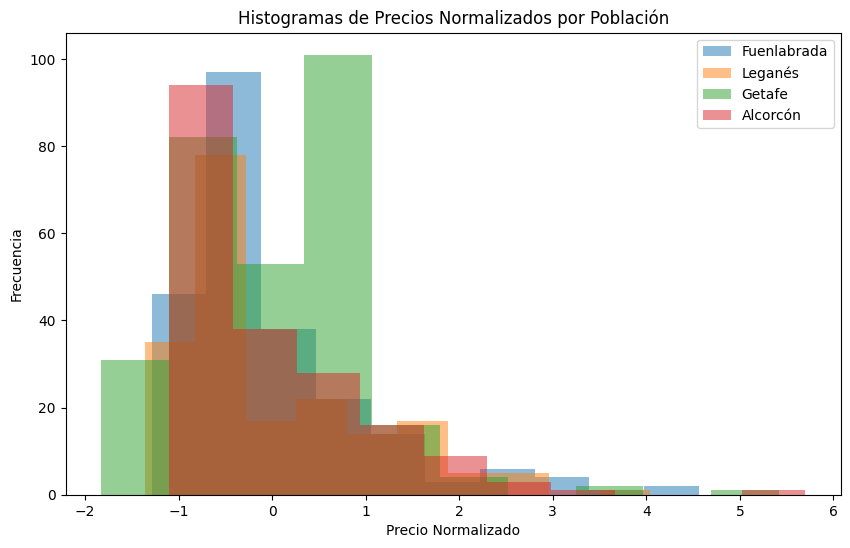

In [338]:
# Normalizar la variable de precios para cada población
subconjunto_cs['price_normalized'] = subconjunto_cs.groupby('level5')['price'].transform(lambda x: (x - x.mean()) / x.std())
import matplotlib.pyplot as plt

# Definir las poblaciones
poblaciones = ['Fuenlabrada', 'Leganés', 'Getafe', 'Alcorcón']

# Crear el gráfico de histogramas
plt.figure(figsize=(10, 6))

# Trazar histogramas para cada población
for poblacion in poblaciones:
    subset = subconjunto_cs[subconjunto_cs['level5'] == poblacion]
    plt.hist(subset['price_normalized'], bins=10, alpha=0.5, label=poblacion)

# Añadir título y etiquetas
plt.title('Histogramas de Precios Normalizados por Población')
plt.xlabel('Precio Normalizado')
plt.ylabel('Frecuencia')
plt.legend()

# Mostrar el gráfico
plt.show()


Fuenlabrada: La distribución de los precios parece estar centrada alrededor del promedio normalizado, con una dispersión moderada.
Leganés: La distribución muestra un sesgo hacia la izquierda, indicando que la mayoría de los precios son inferiores al promedio normalizado.
Getafe: La distribución también está centrada alrededor del promedio, similar a Fuenlabrada, pero con una dispersión diferente.
Alcorcón: Muestra una dispersión mayor en comparación con las otras poblaciones, sugiriendo una mayor variabilidad en los precios.

**TODO: Markdown**. Para escribir aquí, haz doble clic en esta celda, elimina este contenido y coloca lo que quieras escribir. Luego ejecuta la celda.

#### Ejercicio 19. ¿Qué puedes decir sobre el precio por metro cuadrado (precio/m2) entre los municipios de 'Getafe' y 'Alcorcón'? Debes usar el subconjunto obtenido en la pregunta 14 (★★☆)

Pista: Crea una nueva columna llamada `pps` (price per square en inglés) y luego analiza los valores

In [339]:
filtro = subconjunto_cs['level5'].isin(['Getafe', 'Alcorcón'])
cinturon_sur_filtrado = subconjunto_cs[filtro]
# Crear la columna `pps`
cinturon_sur_filtrado['pps'] = cinturon_sur_filtrado['price'] / cinturon_sur_filtrado['surface']
# Descripción estadística para 'Getafe'
getafe_pps = cinturon_sur_filtrado[cinturon_sur_filtrado['level5'] == 'Getafe']['pps']
print("Getafe - Precio por metro cuadrado (pps):")
print(getafe_pps.describe())

# Descripción estadística para 'Alcorcón'
alcorcon_pps = cinturon_sur_filtrado[cinturon_sur_filtrado['level5'] == 'Alcorcón']['pps']
print("\nAlcorcón - Precio por metro cuadrado (pps):")
print(alcorcon_pps.describe())



Getafe - Precio por metro cuadrado (pps):
count     241.000000
mean     2066.314949
std       741.872702
min         0.000000
25%      1684.285714
50%      1973.333333
75%      2628.787879
max      3827.160494
Name: pps, dtype: float64

Alcorcón - Precio por metro cuadrado (pps):
count     173.000000
mean     2239.302480
std       539.951527
min       604.761905
25%      1904.081633
50%      2207.792208
75%      2472.727273
max      3698.159509
Name: pps, dtype: float64


C:\Users\purdi\AppData\Local\Temp\ipykernel_19664\3894637405.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cinturon_sur_filtrado['pps'] = cinturon_sur_filtrado['price'] / cinturon_sur_filtrado['surface']


#### Ejercicio 20. Realiza el mismo gráfico para 4 poblaciones diferentes (columna level5) y colócalos en el mismo gráfico. Debes usar el subconjunto obtenido en la pregunta 14 (★★☆) 
Pista: Haz un diagrama de dispersión de cada población usando subgráficos (subplots).

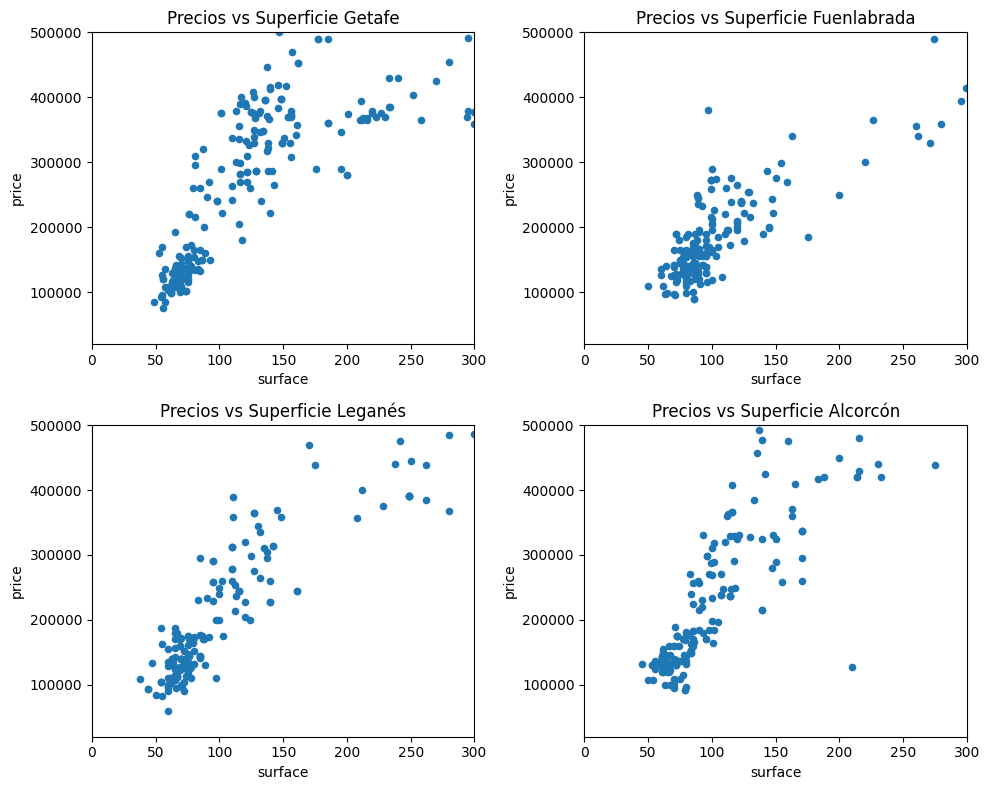

In [340]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

#Getafe en el primer subplot
ds.loc[ds["level5"] == "Getafe", ["price", "surface"]].plot(kind='scatter', x="surface", y="price", ax=axes[0, 0], title="Precios vs Superficie Getafe")
axes[0, 0].set_xlim(0, 300)  
axes[0, 0].set_ylim(20000, 500000) 

# Fuenlabrada en el segundo subplot
ds.loc[ds["level5"] == "Fuenlabrada", ["price", "surface"]].plot(kind='scatter', x="surface", y="price", ax=axes[0, 1], title="Precios vs Superficie Fuenlabrada")
axes[0, 1].set_xlim(0, 300)  
axes[0, 1].set_ylim(20000, 500000)

# Leganés en el tercer subplot
ds.loc[ds["level5"] == "Leganés", ["price", "surface"]].plot(kind='scatter', x="surface", y="price", ax=axes[1, 0], title="Precios vs Superficie Leganés")
axes[1, 0].set_xlim(0, 300)  
axes[1, 0].set_ylim(20000, 500000)

#Alcorcón en el cuarto subplot
ds.loc[ds["level5"] == "Alcorcón", ["price", "surface"]].plot(kind='scatter', x="surface", y="price", ax=axes[1, 1], title="Precios vs Superficie Alcorcón")
axes[1, 1].set_xlim(0, 300)  
axes[1, 1].set_ylim(20000, 500000)
# Ajustar el layout para que no se solapen los títulos y etiquetas
plt.tight_layout()

# Mostrar la figura
plt.show()



#### Ejercicio 21. Realiza un trazado de las coordenadas (columnas latitud y longitud) del cinturón sur de Madrid por color de cada población (debes usar el subconjunto obtenido del Ejercicio 14) (★★★★)

Ejecuta la siguiente celda y luego comienza a codear en la siguiente. Debes implementar un código simple que transforme las columnas de coordenadas en un diccionario de Python (agrega más información si es necesario) y agrégala al mapa.

In [341]:
from ipyleaflet import Map, basemaps

# Map centered on (60 degrees latitude and -2.2 degrees longitude)
# Latitude, longitude
map = Map(center = (60, -2.2), zoom = 2, min_zoom = 1, max_zoom = 20, 
    basemap=basemaps.Stamen.Terrain)
map

AttributeError: Stamen

In [342]:
from ipyleaflet import Map
from xyzservices import get_tile_provider

# Create a Map centered on latitude 60, longitude -2.2 with Stamen Terrain basemap
map = Map(center=(60, -2.2), zoom=2, min_zoom=1, max_zoom=20, 
          basemap=get_tile_provider('Stamen Terrain'))

# Display the map
map


ImportError: cannot import name 'get_tile_provider' from 'xyzservices' (c:\Users\purdi\AppData\Local\Programs\Python\Python312\Lib\site-packages\xyzservices\__init__.py)

#### Exercise 18. Normalize the variable of prices for each population and plot the 4 histograms in the same plot (you must use the subset obtained in Exercise 14) (★★★)

For the normalization method, you can use the one you consider; there is not a single correct answer to this question. Print the plot and write in the Markdown cell a brief analysis about the plot.

Hint: You can help yourself by reviewing the *multihist* demo of Matplotlib.

#### Exercise 18. Normalize the variable of prices for each population and plot the 4 histograms in the same plot (you must use the subset obtained in Exercise 14) (★★★)

For the normalization method, you can use the one you consider; there is not a single correct answer to this question. Print the plot and write in the Markdown cell a brief analysis about the plot.

Hint: You can help yourself by reviewing the *multihist* demo of Matplotlib.

In [ ]:
from ipyleaflet import Map, Marker
import pandas as pd

# Crear el diccionario de coordenadas
coordenadas = []
for index, row in cinturon_sur.iterrows():
    coordenadas.append({
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'level5': row['level5']
    })

# Crear un mapa centrado en una ubicación específica (por ejemplo, Madrid)
mapa = Map(center=(40.3, -3.7), zoom=10)

# Agregar marcadores al mapa
for coord in coordenadas:
    marker = Marker(location=(coord['latitude'], coord['longitude']), title=coord['level5'])
    mapa.add_layer(marker)

# Mostrar el mapa
mapa

Map(center=[40.3, -3.7], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

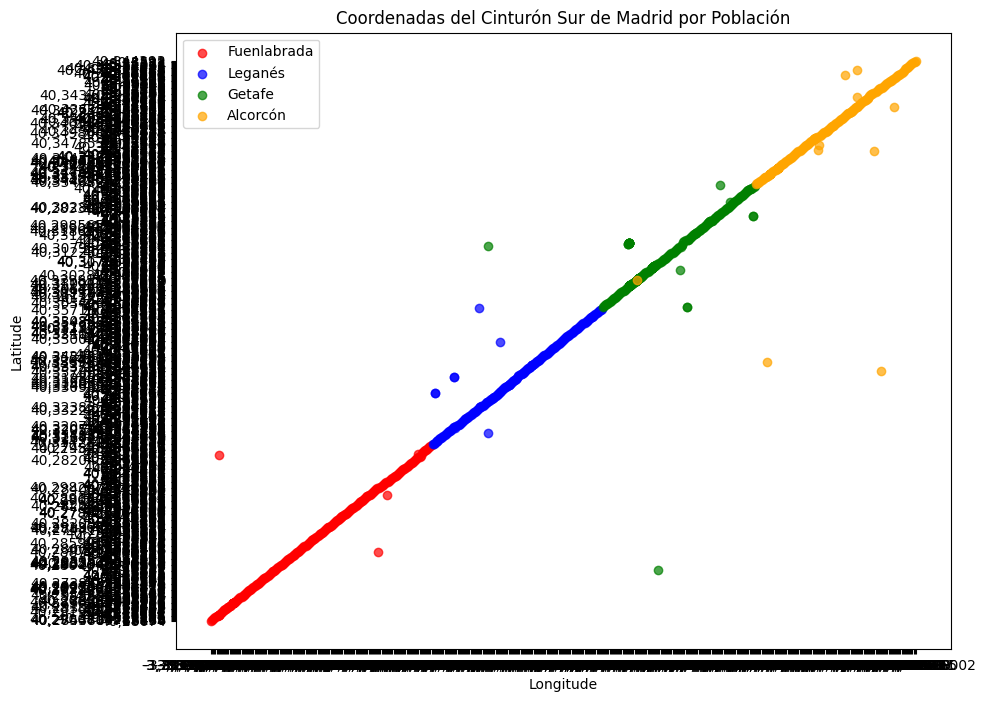

In [ ]:

# Definir colores para cada población
colores = {
    'Fuenlabrada': 'red',
    'Leganés': 'blue',
    'Getafe': 'green',
    'Alcorcón': 'orange'
}

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 8))
for poblacion, color in colores.items():
    df_poblacion = cinturon_sur[cinturon_sur['level5'] == poblacion]
    plt.scatter(df_poblacion['longitude'], df_poblacion['latitude'], color=color, label=poblacion, alpha=0.7)

# Añadir etiquetas y título
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Coordenadas del Cinturón Sur de Madrid por Población')
plt.legend()
